# **Proyecto Final – Data Science 3**

## **Clasificación de reseñas de películas con NLP y Redes Neuronales**




## **Presentación del proyecto**

Este proyecto tiene como objetivo desarrollar un modelo de análisis de sentimientos capaz de clasificar reseñas de películas como positivas o negativas utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y una red neuronal simple implementada en TensorFlow/Keras. Se trabajó con una muestra del conjunto de datos IMDB Movie Reviews, compuesta por reseñas en inglés etiquetadas según su sentimiento. El flujo de trabajo incluyó etapas de preprocesamiento textual —conversión a minúsculas, eliminación de puntuación y eliminación de stopwords—, representación numérica mediante TF-IDF y entrenamiento de una red neuronal densa para la clasificación binaria. El análisis del método summary() permitió interpretar la arquitectura del modelo y la cantidad de parámetros entrenables. Los resultados obtenidos muestran que el modelo alcanza una precisión elevada en la tarea de clasificación, evidenciando la utilidad de las técnicas de NLP y Deep Learning para el análisis automático de opiniones textuales.

## **Motivación y audiencia**

La gran cantidad de opiniones publicadas diariamente en plataformas digitales hace necesario el uso de herramientas automáticas capaces de interpretar el sentimiento expresado por los usuarios. En el ámbito cinematográfico, las reseñas contienen información valiosa sobre la percepción del público y pueden utilizarse para evaluar la recepción de una película. La motivación principal de este trabajo es aplicar conocimientos de NLP y redes neuronales para construir un sistema sencillo que permita identificar automáticamente si una reseña expresa una opinión positiva o negativa.

Este proyecto está dirigido a estudiantes y docentes de ciencia de datos interesados en aplicaciones introductorias de NLP y Deep Learning, así como a personas que deseen comprender el flujo completo de un problema de clasificación de texto: preparación de datos, representación numérica, entrenamiento de modelos y evaluación de resultados.

## **Contexto Comercial**

Las empresas de entretenimiento, plataformas de streaming y sitios de reseñas reciben grandes volúmenes de comentarios de usuarios. Analizar manualmente esas opiniones resulta costoso y poco escalable. Un sistema automático de análisis de sentimientos puede ayudar a detectar rápidamente la percepción general del público, identificar contenidos mejor valorados y apoyar decisiones relacionadas con recomendaciones, campañas de marketing y experiencia del usuario.

## **Contexto Analítico**

Desde el punto de vista analítico, el problema se plantea como una tarea de clasificación supervisada binaria. Las reseñas textuales constituyen la variable de entrada y la etiqueta de sentimiento (positiva o negativa) representa la variable objetivo. El desafío consiste en transformar texto no estructurado en una representación numérica adecuada y entrenar un modelo capaz de generalizar correctamente sobre reseñas no vistas.

## **Preguntas/Hipotesis a resolver**



*   ¿Es posible clasificar automáticamente reseñas de películas en positivas o
negativas utilizando técnicas básicas de NLP?

*   ¿La representación TF-IDF conserva suficiente información para realizar una clasificación efectiva?

*   ¿Una red neuronal densa simple puede alcanzar un desempeño adecuado en esta tarea?


## **Objetivos:**

Desarrollar y evaluar un modelo de análisis de sentimientos para clasificar reseñas de películas del conjunto IMDB como positivas o negativas mediante técnicas de Procesamiento de Lenguaje Natural y una red neuronal simple.

*   Cargar y explorar el conjunto de datos IMDB.

*   Aplicar tareas básicas de preprocesamiento de texto.

*   Convertir las reseñas en vectores numéricos mediante TF-IDF.

*   Construir una red neuronal densa con TensorFlow/Keras.

*   Analizar la arquitectura del modelo utilizando model.summary().

*   Entrenar y evaluar el modelo utilizando métricas de clasificación.

*   Interpretar los resultados obtenidos y discutir posibles mejoras futuras


## **Lectura de datos**

 **Importación de librerias**






In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer


**Carga del dataset**

In [7]:
url = 'https://raw.githubusercontent.com/mariavictoriastrazzolini-sys/proyecto-final-data-science-3/refs/heads/main/IMDB_10000.csv'

df = pd.read_csv(url)

df.head()

,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


**Descipción de las variables.**

| Columnas | Tpo de dato |  Descripcion |
| :-------: | :------: | :-------: |
| review|object| texto de la reseña.|
| sentiment|object| sentimiento asociado (positive o negative).|

In [8]:
df.shape

(10000, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [10]:
df.describe(include='object')

,review,sentiment
count,10000,10000
unique,9978,2
top,I rented this movie because I am a huge Dudiko...,positive
freq,2,5039


In [11]:
df.isna().sum()

,0
review,0
sentiment,0


In [12]:
df.duplicated().sum()

np.int64(22)

In [13]:
df = df.drop_duplicates()

Se detectaron 22 registros duplicados en el conjunto de datos mediante la función duplicated(). Estos registros fueron eliminados utilizando drop_duplicates() con el fin de evitar sesgos en el entrenamiento del modelo.”

## **Análisis exploratorio (EDA)**

**Distribución de clases**

In [14]:
df['sentiment'].value_counts()

,count
sentiment,
positive,5035
negative,4943


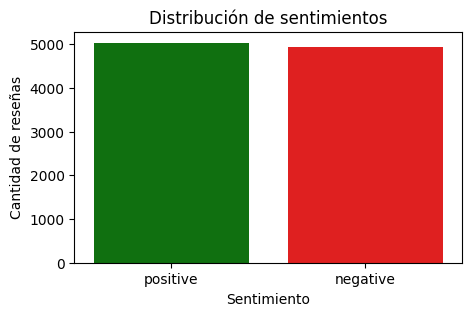

In [15]:
plt.figure(figsize=(5, 3))

sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette={'positive': 'green', 'negative': 'red'},
    legend=False
)

plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de reseñas')
plt.show()

La distribución de reseñas positivas y negativas es equilibrada, por lo que no se observa desbalance significativo entre clases.

**Longitud de las reseñas**

In [16]:
df['review_length'] = df['review'].apply(len)
df['review_length'].describe()

,review_length
count,9978.000000
mean,1314.161455
std,984.048940
min,41.000000
25%,700.000000
50%,975.000000
75%,1596.000000
max,7164.000000


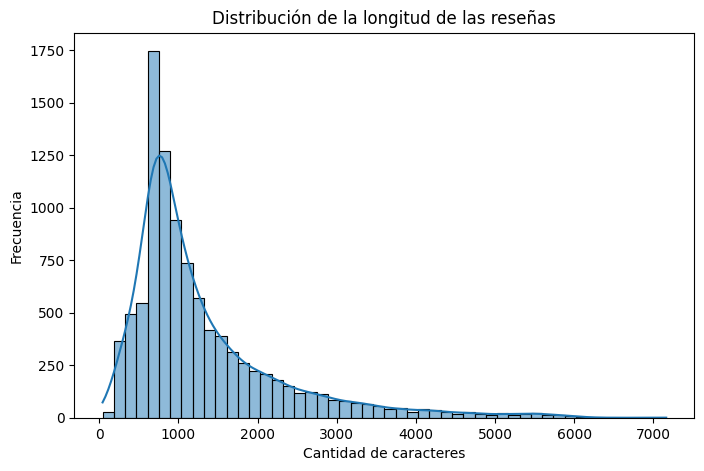

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribución de la longitud de las reseñas')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')
plt.show()

La mayoría de las reseñas tienen entre 500 y 1.500 caracteres, con mayor concentración alrededor de los 700–900. La distribución presenta un sesgo hacia la derecha debido a la presencia de algunas reseñas mucho más extensas.

**Comparación de longitud según sentimiento**

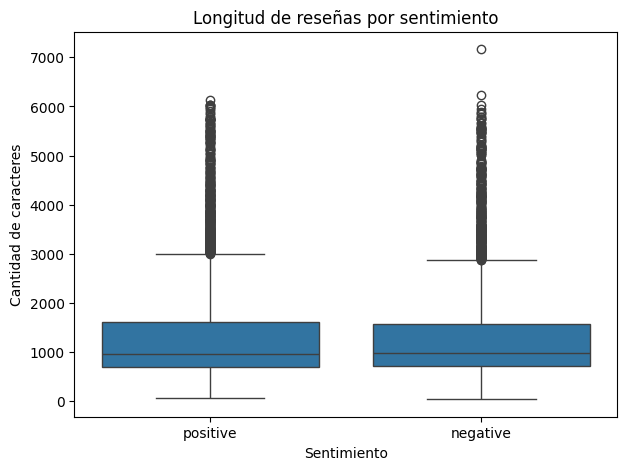

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title('Longitud de reseñas por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de caracteres')
plt.show()

Las reseñas positivas y negativas presentan una distribución de longitud muy similar. En ambos casos, la mayoría se concentra entre aproximadamente 500 y 1.500 caracteres, aunque existen algunos valores atípicos de reseñas mucho más extensas.

**Nube de palabras para reseñas positivas**

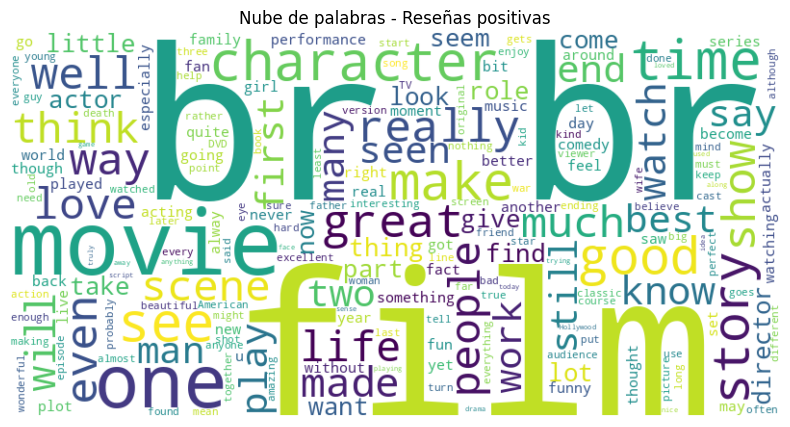

In [19]:
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review'])

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Reseñas positivas')
plt.show()

La nube de palabras de las reseñas positivas muestra que los términos más frecuentes son "film", "movie", "one", "character", "story", "great", "good", "time" y "love". Esto indica que los usuarios valoran principalmente la calidad general de la película, la historia, los personajes y la experiencia de verla. Además, la presencia de palabras con connotación positiva como great, good, love y best refleja un alto nivel de satisfacción y una percepción favorable por parte de los espectadores.

**Nube de palabras para reseñas negativas**

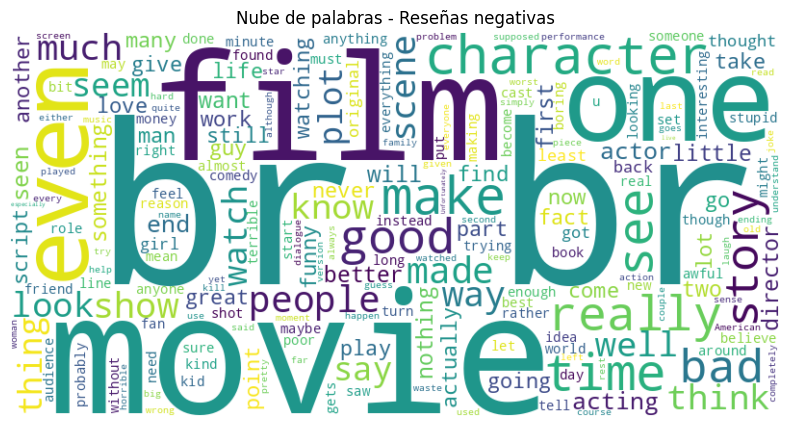

In [20]:
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review'])

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Reseñas negativas')
plt.show()

La nube de palabras de las reseñas negativas muestra que los términos más frecuentes son "movie", "film", "character", "time", "acting", "plot", "director" y "script". Esto indica que las críticas se enfocan principalmente en aspectos relacionados con la calidad de la película, como la actuación, el desarrollo de los personajes, el guion y la trama. La presencia de palabras como bad, boring, better y really refleja el descontento de los espectadores y su percepción de que la película no cumplió con sus expectativas.

## **Preprocesamiento de datos**

**Limpieza de textos:**

*   Conversión a minúsculas.
*   Eliminación de puntuación y caracteres especiales.
*   Eliminación espacios extra
*   Eliminación de stopwords.


In [21]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))


def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    texto = re.sub(r'\s+', ' ', texto).strip()

    palabras = [palabra for palabra in texto.split()
                if palabra not in stop_words]

    return ' '.join(palabras)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
df['review_clean'] = df['review'].apply(limpiar_texto)

In [23]:
df[['review', 'review_clean']].head()

,review,review_clean
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
1,Not many television shows appeal to quite as m...,many television shows appeal quite many differ...
2,The film quickly gets to a major chase scene w...,film quickly gets major chase scene ever incre...
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve onebr br ...
4,Expectations were somewhat high for me when I ...,expectations somewhat high went see movie thou...


## **Codificación de la variable objetivo**

In [24]:
y = df['sentiment'].map({'negative':0, 'positive':1})

print(y.head())

0    1
1    1
2    0
3    1
4    0
Name: sentiment, dtype: int64


La variable sentiment fue convertida a formato numérico mediante una codificación binaria, asignando 1 a las reseñas positivas y 0 a las negativas.
Esta transdormación fue realizada para utilizar la variable objetivo en modelos de aprendizaje automatico y redes neuronales

## **División del conjunto de datos**

In [25]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['review_clean'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_text.shape)
print(X_test_text.shape)

(7982,)
(1996,)


El conjunto de datos se dividió en entrenamiento (80%) y prueba (20%) utilizando train_test_split, manteniendo la proporción de clases mediante estratificación.

## **Vectorización del texto (TF-IDF)**

In [26]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)

(7982, 5000)
(1996, 5000)


El vectorizador TF-IDF se ajustó exclusivamente sobre el conjunto de entrenamiento con el fin de evitar la fuga de información (data leakage). Posteriormente, el conjunto de prueba fue transformado utilizando el mismo vocabulario y los pesos aprendidos durante el entrenamiento, garantizando una evaluación objetiva del modelo.

## **Construcción de la Red Neuronal**

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(128,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dense(64,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura del modelo está compuesta por dos capas ocultas de 128 y 64 neuronas con activación ReLU y una capa de salida con activación Sigmoid, adecuada para clasificación binaria. En total, la red posee 648.449 parámetros entrenables, que serán ajustados durante el proceso de entrenamiento.

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## **Entrenamiento del modelo **

In [30]:
history = model.fit(
    X_train.toarray(),
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8067 - loss: 0.4312 - val_accuracy: 0.8591 - val_loss: 0.3218
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9442 - loss: 0.1594 - val_accuracy: 0.8416 - val_loss: 0.3979
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9821 - loss: 0.0644 - val_accuracy: 0.8359 - val_loss: 0.5273
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9956 - loss: 0.0210 - val_accuracy: 0.8309 - val_loss: 0.6458
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9997 - loss: 0.0047 - val_accuracy: 0.8297 - val_loss: 0.7458
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8284 - val_loss: 0.8075
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 1.0000 - loss: 6.8849e-04 - val_accuracy: 0.8291 - val_loss: 0.8483
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 4.5773e-04 - 

## **Evolución del Accuracy**

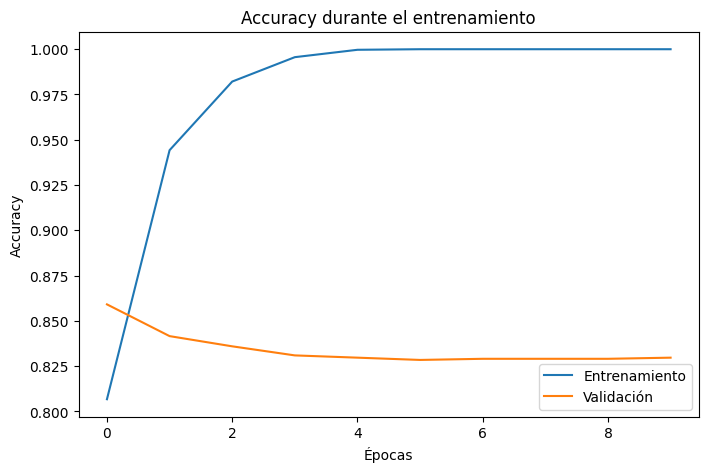

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()

plt.show()

## **Evolución del Loss**

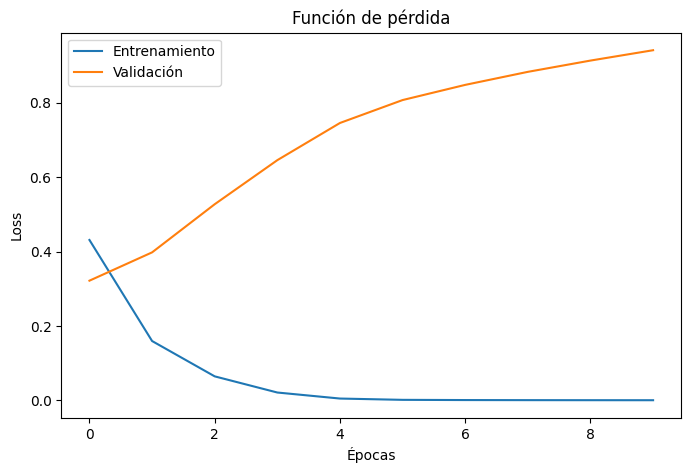

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Función de pérdida")
plt.legend()

plt.show()

Los gráficos de accuracy y loss muestran indicios de sobreajuste, ya que el modelo obtiene un excelente desempeño sobre los datos de entrenamiento, pero pierde capacidad para generalizar sobre los datos de validación. Por este motivo, a continuación se implementan mejoras en la arquitectura de la red para reducir este comportamiento y obtener un modelo más robusto.

## **Mejora de la Red Neuronal**

En línea con la consigna de la Entrega Final, se optó por profundizar en la actividad de Deep Learnin. Para mejorar la capacidad de generalización del modelo, se construyó una nueva arquitectura incorporando más neuronas, capas de regularización (Dropout) y la técnica de EarlyStopping, que permite detener el entrenamiento cuando el modelo deja de mejorar sobre los datos de validación.

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential()

model2.add(Dense(256,
                 activation='relu',
                 input_shape=(X_train.shape[1],)))

model2.add(Dropout(0.3))

model2.add(Dense(128,
                 activation='relu'))

model2.add(Dropout(0.5))

model2.add(Dense(64,
                 activation='relu'))

model2.add(Dense(1,
                 activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

La segunda red neuronal incorpora una arquitectura más profunda, con tres capas ocultas de 256, 128 y 64 neuronas, además de dos capas Dropout para reducir el sobreajuste. En total, el modelo cuenta con 1.321.473 parámetros entrenables, aproximadamente el doble que la primera red, lo que le permite aprender patrones más complejos.


In [49]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
early = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## **Entrenamiento**

In [51]:
history2 = model2.fit(
    X_train.toarray(),
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early],
    verbose=1
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7821 - loss: 0.4459 - val_accuracy: 0.8560 - val_loss: 0.3280
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9347 - loss: 0.1794 - val_accuracy: 0.8522 - val_loss: 0.3957
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9826 - loss: 0.0583 - val_accuracy: 0.8391 - val_loss: 0.5350
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9953 - loss: 0.0188 - val_accuracy: 0.8372 - val_loss: 0.7336


## **Evolución del Accuracy**

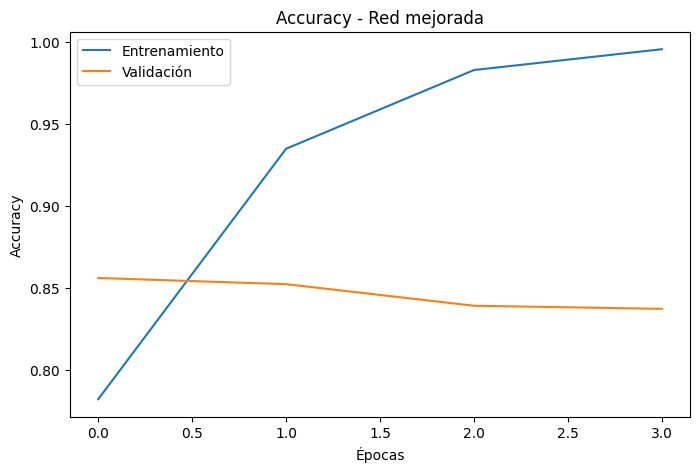

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['accuracy'], label='Entrenamiento')
plt.plot(history2.history['val_accuracy'], label='Validación')

plt.title("Accuracy - Red mejorada")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Se observa que la precisión del entrenamiento aumenta rápidamente hasta alcanzar valores cercanos al 100%, mientras que la precisión de validación disminuye levemente con el paso de las épocas. Esto indica que, a pesar de las mejoras incorporadas en la arquitectura, el modelo continúa presentando sobreajuste y no logra mejorar su capacidad para generalizar sobre datos nuevos.

## **Evolución del Loss**

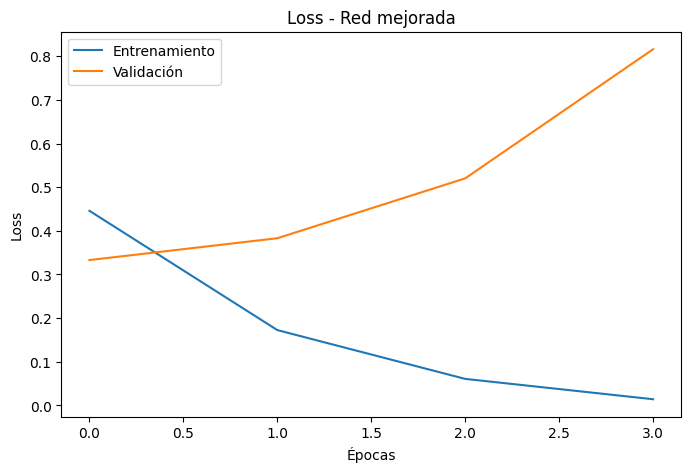

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')

plt.title("Loss - Red mejorada")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

La pérdida del entrenamiento disminuye progresivamente hasta valores muy bajos, mientras que la pérdida de validación aumenta a medida que avanzan las épocas. Este comportamiento confirma que el modelo sigue sobreajustándose, ya que aprende cada vez mejor los datos de entrenamiento, pero aumenta el error sobre los datos de validación.

Se propuso una segunda arquitectura para reducir el sobreajuste. Si bien se incorporaron técnicas de regularización como Dropout y EarlyStopping, los resultados muestran que el modelo continuó presentando diferencias entre el rendimiento de entrenamiento y validación. Esto indica que las modificaciones realizadas no fueron suficientes para mejorar la capacidad de generalización.

## **Predicciones**

In [53]:
y_prob = model2.predict(X_test.toarray())

y_pred = (y_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


## **Evaluación del modelo**

**Accuracy**

In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8717


**Precision, Recall y F1 Score**

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.8804457953394124
Recall: 0.8629592850049652
F1 Score: 0.8716148445336008


El modelo obtuvo una accuracy de 87,17%, lo que indica que clasificó correctamente la mayoría de las reseñas del conjunto de prueba. Además, las métricas de Precision (88,04%), Recall (86,29%) y F1 Score (87,16%) presentan valores elevados y equilibrados, evidenciando un buen desempeño general en la clasificación de reseñas positivas y negativas.

**Matriz de confusión**

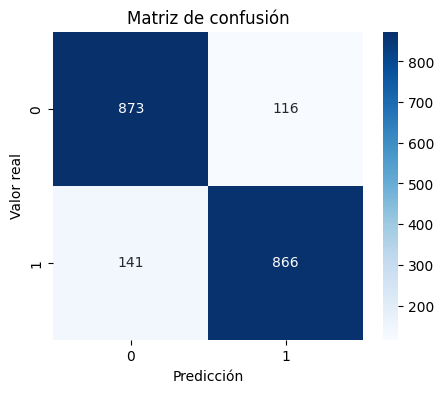

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

La matriz de confusión muestra que el modelo clasificó correctamente 873 reseñas negativas y 866 reseñas positivas. Además, cometió 116 falsos positivos y 141 falsos negativos. En general, el modelo presenta un buen desempeño, ya que la mayoría de las predicciones corresponden a la clase correcta.

**Reporte de clasificación**

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       989
           1       0.88      0.86      0.87      1007

    accuracy                           0.87      1996
   macro avg       0.87      0.87      0.87      1996
weighted avg       0.87      0.87      0.87      1996



El reporte de clasificación muestra un desempeño equilibrado para ambas clases. Tanto las reseñas positivas como las negativas obtuvieron valores cercanos al 87% en precisión, recall y F1 Score, lo que indica que el modelo mantiene un rendimiento similar al clasificar ambas categorías.

**Curva AUC-ROC**




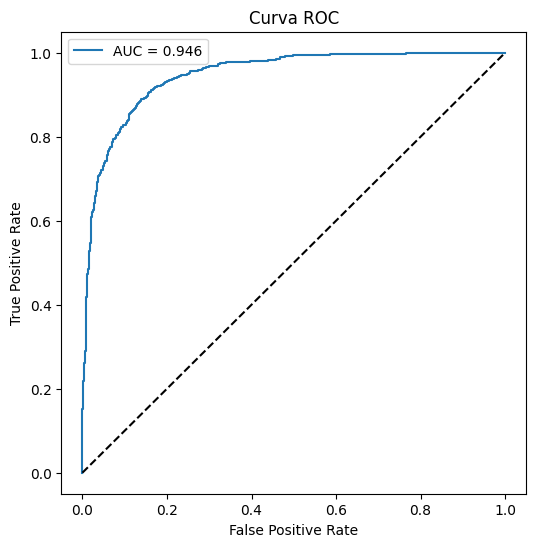

In [57]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

La curva ROC se encuentra muy por encima de la línea de referencia, lo que indica una buena capacidad del modelo para distinguir entre reseñas positivas y negativas. Además, el valor AUC = 0,946 refleja un excelente desempeño en la clasificación.

## **Conclusiones finales**

En este proyecto se desarrolló un modelo de análisis de sentimientos utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning para clasificar reseñas de películas como positivas o negativas. Como parte del preprocesamiento, se limpiaron los textos y se representaron mediante la técnica TF-IDF, lo que permitió transformar la información textual en variables numéricas aptas para el entrenamiento de la red neuronal.

Posteriormente, se construyó una red neuronal profunda para realizar la clasificación de las reseñas. Durante el entrenamiento se observó un buen desempeño sobre los datos de entrenamiento, aunque las curvas de accuracy y loss evidenciaron la presencia de sobreajuste. Para intentar reducir este comportamiento se incorporaron más capas, Dropout y EarlyStopping, aunque el modelo continuó mostrando presentando indicios de sobreajuste.

A pesar de ello, el modelo obtuvo resultados satisfactorios sobre el conjunto de prueba, alcanzando una accuracy de 87,17%, un F1 Score de 87,16% y un AUC de 0,946, lo que demuestra una buena capacidad para clasificar correctamente las reseñas positivas y negativas.

En conclusión, este trabajo permitió aplicar de forma práctica conceptos de NLP y Deep Learning, desde el preprocesamiento de texto hasta la construcción y evaluación de una red neuronal, analizando tanto sus fortalezas como sus limitaciones.